<a href="https://colab.research.google.com/github/eduardodpms/UnB_Notebooks/blob/main/25.2%20TEMA/Trabalho%201/tema1_25_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho 1 - *TEMA 2025/2***

## **Universidade de Brasília** - *Faculdade de Ciências e Tecnologias em Engenharia*

## *Primeiro Trabalho de Tópicos Especiais em Matemática Aplicada - 2025/2*

- Docente: Vinícius de Carvalho Rispoli

- Discente: Eduardo de Pina Moreira Santos

- Matrícula: 231034494

## **Sumário**

1. [***Introdução***](#1.)
2. [***Metodologia***](#2.)
3. [***Análise e Tratamento do Dataset***](#3.)
4. [***Modelo From Scratch***](#4.)
5. [***Modelo Transfer Learning***](#5.)
6. [***Comparação: From Scratch X Transfer Learning***](#6.)
6. [***Validação Final***](#7.)
7. [***Conclusão***](#8.)
8. [***Referências***](#9.)

<a name="1."></a>
## **1. Introdução**

Este trabalho corresponde ao projeto desenvolvido para a primeira atividade avaliativa da disciplina de *Tópicos Especiais em Matemática Aplicada* na **UnB**. Nesse sentido, a fim de desenvolver o conhecimento dos estudantes no que tange a modelos de linguagem utilizando o *Pytorch*, foi proposto que os mesmos desenvolvessem uma rede neural classificadora de aves com base em um banco de imagens com cerca de 2800 elementos, divididos em 14 classes. Para isso, deve ser seguida a seguinte sequência de passos no projeto:

1. *Análise Exploratória do Dataset;*
2. *Pré-Processamento e Data Augmentation;*
3. *Construção de uma rede "from scratch" do Pytorch;*
4. *Transfer Learning + Fine Tuning em um modelo pré-treinado;*
5. *Análise, comparação e validação de Resultados.*

Antes de iniciar esse desenvolvimento, foi elaborada a metodologia a ser seguida no projeto, definida no tópico [*2. Metodologia*](#2.).

<a name="2."></a>
## **2. Metodologia**

A primeira etapa do desenvolvimento do projeto consistiu na elaboração de uma metodologia "parcial" eficiente, para ser seguida no contexto do problema. Essa metodologia pôde ser dividida em **6 fases** principais, listadas e descritas abaixo:

### 1. *Entendimento do Problema e do Dataset*

- A fase inicial consistiu no entendimento do material disponibilizado para o trabalho. Com um documento descritivo dos passos, do *Dataset* e de outras instruções, além de um processo de observação visual das imagens dos conjuntos disponibilizados, foi feito um *brainstorming* para o entendimento de como seriam desenvolvidos os artefatos da atividade.


### 2. *Pesquisa e Levantamento de Informações*

- Seguindo a etapa de *brainstorming*, foi feita uma busca extensiva de dados na *internet*, em veículos acadêmicos e em *chatbots*, com o intuido de separar e organizar as ferramentas mais adequadas para o projeto, além de uma série de outras informações para o ampliar o conhecimento e proporcionar um desenvolvimento mais limpo e mais consciente do trabalho.

### 3. *Elaboração e treinamento do modelo from scratch*

- Depois, iniciou-se a elaboração do primeiro modelo, *from scratch*, utilizando todo o material obtido na etapa de pesquisa. Foram testados diversos conjuntos de arquitetura e de parâmetros, a fim de se obter um resultado que atendesse bem às expectativas.

### 4. *Importação e fine-tuning do modelo pré-treinado*

- Também com uma base obtida na etapa de pesquisa, aplicaram-se técnicas novas e diferentes daquelas utilizadas na elaboração do modelo *from scratch* com o intuito de importar um modelo com *Transfer Learning* e aplicar *Fine Tuning* para o *Dataset* do problema. Aqui, também foram realizados inúmeros testes de modelos e parâmetros diferentes, buscando sempre um desempenho melhor.

### 5. *Validação e análise de resultados*

- Após o desenvolvimento bem-sucedido dos dois modelos e a obtenção das métricas de treinamento dos dois modelos, o próximo passo consistiu na análise e comparação dos resultados ao longo das épocas e no levantamento de hipóteses dos mesmos, bem como na validação final do modelo com melhor desempenho por meio da utilização de um *Dataset* dedicado.

### 6. *Organização do código e divisão dos tópicos*

- Por fim, com o código finalizado, seguiu-se para uma etapa de organização do mesmo, removendo trechos desnecessários e melhorando a visualização, de divisão e separação dos tópicos no notebook e, ao final, de elaboração dos textos explicativos.

<br>

Após a elaboração parcial da **metodologia**, iniciou-se todo o desenvolvimento representado nela. Para acompanhar o resultado desse desenvolvimento, siga para o primeiro tópico prático do trabalho: [*3. Análise e Tratamento do Dataset*](#3.).

<a name="3."></a>
## **3. Análise e Tratamento do *Dataset***

Nesse tópico, faremos a análise e o tratamento cabível no *Dataset*, antes de partirmos para a elaboração dos modelos.

<a name="3.1."></a>
### *3.1. Importações*

Iniciamos o código fazendo todas as importações de bibliotecas que serão utilizadas ao longo do notebook.

In [ ]:
# Importação de bibliotecas do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR, LambdaLR
from torchvision import datasets, transforms, utils
from torch.utils.data import random_split, DataLoader, Dataset
from torch import amp

# Importação de bibliotecas diversas
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import timm
import math
import time
import os

Depois, importamos os *Datasets* do *Google Drive*. Eles estão divididos da seguinte maneira:

- O *Dataset* **principal**, com cerca de 2800 imagens, será dividido parcelas de **treinamento** e de **validação durante o treinamento**, com a finalidade de acompanharmos a evolução da convergência do modelo e monitorarmos problemas de *fitting*.
- O *Dataset* **de validação** possui um número reduzido de imagens e só será utilizado na [**Validação Final**](#7.), sem *data augmentation*.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/aves.zip > /dev/null # Descompacta o arquivo contendo o Dataset
!unzip /content/drive/MyDrive/aves_val.zip > /dev/null # Descompacta o arquivo contendo o Dataset de Validação

Mounted at /content/drive


In [ ]:
full_dir = '/content/aves' # Diretório do dataset de treinamento/teste
val_dir = '/content/aves_val' # Diretório do dataset de validação final

In [ ]:
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()]) # Transforms para aplicação no treinamento
full_dataset = datasets.ImageFolder(root=full_dir, transform=transform) # Carrega o dataset do diretório

Aqui, definimos os caminhos para os arquivos e carregamos as imagens do *Dataset* **principal** e aplicamos transforms simples:

- **Resize:** Reduz a escala das imagens para *224x224* (formato padrão do Pytorch);
- **ToTensor:** Transforma as imagens em vetores multidimensionais (tensores).

<a name="3.2."></a>
### *3.2. Configuração e Análise Exploratória*

Aqui, faremos uma breve análise do *Dataset*, com base em informações disponíveis no [guia para o trabalho](https://drive.google.com/file/d/1cHeJGI8Xcws0-REwuJ6sOu5BkbxKlumC/view?usp=drive_link) e na *internet*.

Para isso, criaremos um dicionário para tradução dos nomes das aves entre **nome científico** (nome original das classes) e **nome popular** (facilita a leitura e a visualização). Além disso, também vamos visualizar uma contagem de elementos por meio de um *DataFrame*.

In [ ]:
# Gera um dicionário para traduções Nome Científico -> Nome Popular
names = {
  'amazona_aestiva': 'Papagaio-verdadeiro',
  'amazona_amazonica': 'Curica',
  'anodorhynchus_hyacinthinus': 'Arara-azul',
  'ara_ararauna': 'Arara-canindé',
  'ara_chloropterus': 'Arara-vermelha',
  'ara_macao': 'Araracanga',
  'brotogeris_chiriri': 'Periquito-de-encontro-amarelo',
  'diopsittaca_nobilis': 'Maracanã-pequena',
  'eupsittula_aurea': 'Periquito-rei',
  'forpus_xanthopterygius': 'Tuim',
  'orthopsittaca_manilatus': 'Maracanã-do-buriti',
  'primolius_maracana': 'Maracanã',
  'psittacara_leucophthalmus': 'Periquitão',
  'touit_melanonotus': 'Apuim-de-costas-pretas'
}

# Gera um DataFrame para o dataset
full_df = pd.DataFrame(data={
  'Nome Científico': full_dataset.classes,
  'Nome Popular': [names[name] for name in full_dataset.classes],
  'Contagem de Imagens': [len(os.listdir(os.path.join(full_dir, name))) for name in full_dataset.classes]
})

In [ ]:
# Exibe as informações do dataset
print(f'Total de imagens: {len(full_dataset)}\n')
full_df.style.set_caption("Contagem de Imagens por Classe").hide(axis=0)

Total de imagens: 2879



Nome Científico,Nome Popular,Contagem de Imagens
amazona_aestiva,Papagaio-verdadeiro,240
amazona_amazonica,Curica,189
anodorhynchus_hyacinthinus,Arara-azul,250
ara_ararauna,Arara-canindé,240
ara_chloropterus,Arara-vermelha,203
ara_macao,Araracanga,172
brotogeris_chiriri,Periquito-de-encontro-amarelo,186
diopsittaca_nobilis,Maracanã-pequena,217
eupsittula_aurea,Periquito-rei,216
forpus_xanthopterygius,Tuim,215


Podemos observar que temos 14 classes de aves psitaciformes, cada uma com cerca de 200 imagens RGB de exemplares dessas espécies em poses diversas. Sobre essas informações, é possível inferir alguns pontos importantes para a análise:

- Temos um número reduzido de imagens. Isso indica que será necessária a aplicação alguma técnica de aumento de imagens, a fim de proporcionar variabilidade no conjunto e garantir melhores resultados no treinamento;

- No *Dataset*, temos imagens em excelente qualidade e que destacam as características das aves, assim como temos também imagens "de má qualidade", as quais dificultam a diferenciação das espécies até para olhares humanos;

- O modelo que elaborarmos terá que se basear em características únicas e distintivas das aves. Isso aponta para a necessidade do uso de uma **Rede Neural Convolucional**, que possui a capacidade de reconhecer elementos distintivos por meio da **Convolução**. Nesse caso, as principais características são a **cor da pelagem** e o **formato do corpo**;

Com base nessas inferências, podemos seguir para o *splitting* e *data augmentation* do nosso *Dataset*.

<a name="3.3."></a>
### *3.3. Split e Data Augmentation*

Nessa etapa, definiremos os *Data Loaders* para o *Dataset* **principal**, que são uma ferramenta do *Pytorch* para a geração de imagens alteradas **durante o treinamento**. Depois do *splitting* entre `train` e `test`, é importante que o *data augmentation* seja aplicado **somente** no **conjunto de treinamento**, pois o conjunto de teste só será utilizado para avaliação. Para isso, devemos criar um elemento *Subset* do *Pytorch* customizado, a fim de que o conjunto de teste não receba os transforms.

Definiremos o tamanho do **batch** utilizado pelo *data loader*, bem como a proporção do *splitting*, e depois a classe para o nosso *Subset* customizado e o nosso conjunto de *transforms*, e seguiremos para a criação dos *data loaders* em si.

In [ ]:
batch_size = 32 # Tamanho do lote de treinamento
train_ratio = 0.9 # Proporção do dataset para treinamento

In [ ]:
# Arquitetura customizada de dataset, para aplicação póstuma de transforms
class TransformedSubset(Dataset):
  def __init__(self, subset, transform):
    self.subset = subset
    self.transform = transform
  def __getitem__(self, index):
    x, y = self.subset[index]
    return self.transform(x), y
  def __len__(self):
    return len(self.subset)

# Transforms para o conjunto de treinamento
train_transform = transforms.Compose([
  transforms.RandomHorizontalFlip(),
  transforms.RandomResizedCrop(224),
  transforms.ColorJitter(0.1, 0.1, 0.1, 0.02),
  transforms.RandomErasing(),
  transforms.RandomRotation(15)
])

Os *transforms* utilizados no *data augmentation* serão:

- **Random Horizontal Flip:** *Inverte a imagem horizontalmente;*
- **Random Resized Crop:** *Recorta um trecho da imagem e o redimensiona;*
- **Color Jitter:** *Muda levemente o esquema de cores da imagem;*
- **Random Erasing:** *Apaga aleatoriamente trechos retangulares das imagens;*
- **Random Rotation:** *Rotaciona levemente as imagens.*

In [ ]:
# Dividir o dataset em treino e teste
train_size = int(train_ratio * len(full_dataset))
test_size = len(full_dataset) - train_size
train_subset, test_subset = random_split(full_dataset, [train_size, test_size])
print(f'train = {train_size}, test = {test_size}')

# Criar Datasets com transforms adequados para o treino
train_dataset = TransformedSubset(train_subset, train_transform)

# Criar DataLoader para treino e teste
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

train = 2591, test = 288


<a name="3.4."></a>
### *3.4. Visualização de amostras aumentadas*

Aqui, podemos observar exemplos de imagens geradas pelo *Data Loader* do conjunto de treinamento. Note que os *transforms* aplicados proporcionam grande variabilidade nas imagens, sem ignorar as características discriminatórias das aves.

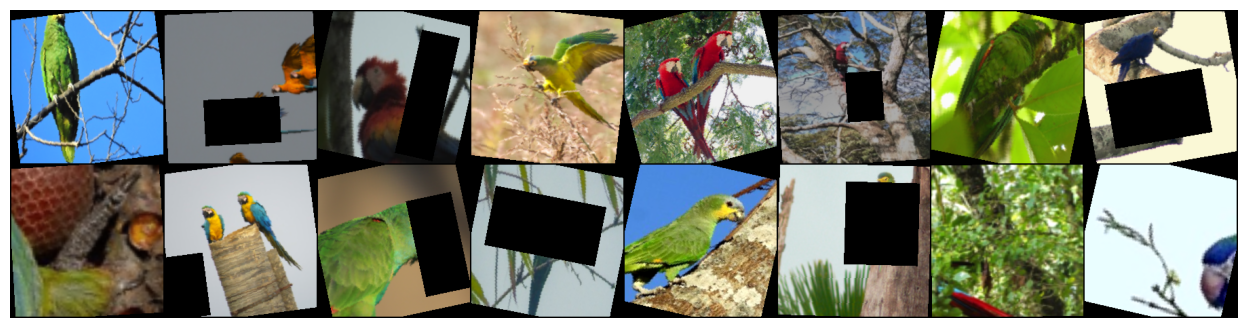

In [ ]:
# Visualizar exemplos de imagens aumentadas
images, labels = next(iter(train_loader))
grid_img = utils.make_grid(images[:16])
plt.figure(figsize=(20, 4))
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()

<a name="4."></a>
## **4. Modelo *From Scratch***

Aqui, iniciaremos a elaboração do nosso modelo *From Scratch* para a classificação das aves.

<a name="4.1."></a>
### *4.1. Configuração inicial e Definição de classes/funções*

Iniciaremos definindo as variáveis que serão utilizadas localmente para o modelo, assim como o nosso *hardware* (preferencialmente *GPU*).

In [ ]:
# Configurações gerais
num_classes = 14 # Número de classes
num_epochs = 40 # Número de épocas de treinamento
dropout = 0.6 # Dropout
max_lr = 1e-2 # Valor máximo do Learning Rate adaptativo
weight_decay = 1e-4 # Decay de pesos
seed = 42 # Semente para aleatorização
validation = True # Se o test_loader deve ser utilizado para validação durante o treinamento

# Dispositivo de Hardware disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Acessar a GPU, se disponível
print(f'Device: {device}') # Verificar dispositivo disponível

torch.manual_seed(seed)
if device.type == 'cuda':
  torch.cuda.manual_seed_all(seed)

Device: cuda


Aqui, definiremos a arquitetura do nosso modelo **Convolucional**. Ele será composto por 4 camadas convolucionais, todas seguidas por camadas de **batch normalization**, de **ativação** e de **pooling**. O nosso classificador, por sua vez, será composto por uma camada **simples**, uma de **ativação**, uma de **batch normalization** com *dropout*, e a camada de saída.

Além disso, definiremos também uma função para inicialização normalizada dos parâmetros da rede.

In [ ]:
# Classe para a rede From Scratch
class ScratchCNN(nn.Module):
  def __init__(self, num_classes, dropout):
    super().__init__()
    self.features = nn.Sequential(
      nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
      nn.MaxPool2d(2), # 112
      nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
      nn.MaxPool2d(2), # 56
      nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
      nn.MaxPool2d(2), # 28
      nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
      nn.AdaptiveAvgPool2d(1)
    )
    self.classifier = nn.Sequential(
      nn.Dropout(0.4),
      nn.Linear(256, 256),
      nn.ReLU(inplace=True),
      nn.BatchNorm1d(256),
      nn.Dropout(dropout),
      nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x


# Função para inicialização de pesos
def init_weights(m):
  if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    if getattr(m, 'bias', None) is not None:
      nn.init.zeros_(m.bias)
  elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
    nn.init.ones_(m.weight), nn.init.zeros_(m.bias)


# Função para cálculo das acurácias
def accuracy(outputs, targets):
  preds = outputs.argmax(dim=1)
  return (preds == targets).sum().item()

<a name="4.2."></a>
### *4.2. Criação do modelo e Definição de parâmetros*

Aqui, criamos o objeto do nosso modelo e inicializamos os seus pesos, além de migrar-lo para a *GPU* (se disponível).

In [ ]:
# Criação e migração do modelo
model = ScratchCNN(num_classes, dropout)
model.apply(init_weights)
model = model.to(device)

Depois, definimos o nosso otimizador, com learning rate adaptativo (scheduler). Para essa tarefa de classificação, a escolha de otimizador se deu após alguns testes, que forneceram resultados melhores com o uso do **SGD**. Também definimos a **função de perda** e o **scaler**.

In [ ]:
# Definição do Otimizador
optimizer = optim.SGD(model.parameters(), lr=max_lr, momentum=0.9, weight_decay=weight_decay)

# Definição do Scheduler
assert 'train_loader' in globals(), "Defina train_loader no ambiente."
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr, epochs=num_epochs, steps_per_epoch=steps_per_epoch,
                       pct_start=0.1, anneal_strategy='cos', div_factor=25.0)

# Definição da Função de Perda e do Scaler
criterion = nn.CrossEntropyLoss()
scaler = amp.GradScaler(device)

# Definição de variáveis pré-treinamento
global_step, best_acc = 0, 0.0
scratch_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

<a name="4.3."></a>
### *4.3. Treinamento do modelo*

Aqui, iniciaremos o loop de treinamento. Utilizaremos os *Data Loaders*  para a avaliação da época na etapa de validação dentro da época, e para a geração de imagens aumentadas na etapa de ajuste de pesos. Rodaremos 40 épocas, acompanhando a evolução das métricas.

In [ ]:
# Loop principal de treinamento
for epoch in range(num_epochs):
    model.train()
    running_correct, running_total, running_loss = 0, 0, 0.0
    start_time = time.time()


    # ========== Training on train_loader ==========
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1:02d}/{num_epochs} [train]")
    for batch_idx, (inputs, targets) in pbar:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()

        with amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        global_step += 1

        running_loss += loss.item() * inputs.size(0)
        running_correct += accuracy(outputs.detach(), targets)
        running_total += inputs.size(0)

        pbar.set_postfix({
            'loss': f"{running_loss / running_total:.4f}",
            'acc': f"{(running_correct / running_total)*100:.2f}%",
            'lr': scheduler.get_last_lr()[0]
        })

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    scratch_history['train_loss'].append(epoch_loss), scratch_history['train_acc'].append(epoch_acc)
    finish = f"| Epoch {epoch+1:02d} finished in {time.time() - start_time:.1f}s |"


    # ========== Validation on test_loader ==========
    if validation:
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        pbar = tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs}  [val]")
        with torch.no_grad():
            for inputs, targets in pbar:
                inputs = inputs.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)
                with amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                val_correct += accuracy(outputs, targets)
                val_total += inputs.size(0)

                pbar.set_postfix({
                'val_loss': f"{val_loss / val_total:.4f}",
                'val_acc': f"{(val_correct / val_total)*100:.2f}%"
            })

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        scratch_history['val_loss'].append(val_loss), scratch_history['val_acc'].append(val_acc)


    print(f'{"="*int((118-len(finish))/2)}{finish}{"="*int((118-len(finish))/2)}') # Epoch's info


print(f'\n{"-"*31}| Training completed. Best {"val" if validation else "train"}_acc = {(best_acc*100):.2f}% (Epoch {epoch:02d}) |{"-"*31}')

Epoch 01/40 [train]:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 01/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

============================================| Epoch 01 finished in 56.1s |============================================


Epoch 02/40 [train]:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 02/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 39/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

============================================| Epoch 39 finished in 52.7s |============================================


Epoch 40/40 [train]:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 40/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

============================================| Epoch 40 finished in 52.2s |============================================

-------------------------------| Training completed. Best val_acc = 0.00% (Epoch 39) |-------------------------------


Após a conclusão do treinamento do modelo *from scratch*, vamos seguir para a avaliação do mesmo no próximo tópico.

<a name="4.4."></a>
### *4.4. Avaliação do treinamento*

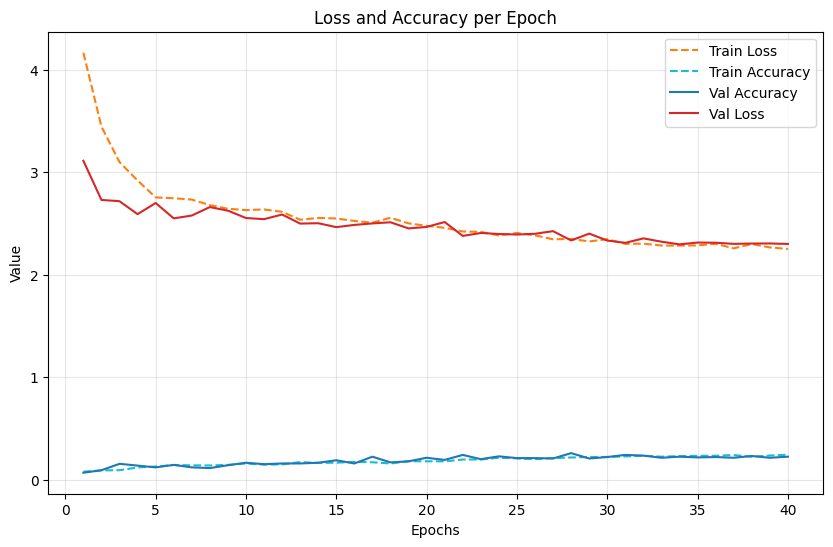

In [ ]:
# Exibe as acurácias e losses de treinamento e de validação
epochs = range(1, len(scratch_history['train_loss']) + 1)
plt.figure(figsize=(10, 6))

plt.plot(epochs, scratch_history['train_loss'], label='Train Loss', color='tab:orange', linestyle='--')
plt.plot(epochs, scratch_history['train_acc'], label='Train Accuracy', color='tab:cyan', linestyle='--')

if validation:
  plt.plot(epochs, scratch_history['val_acc'], label='Val Accuracy', color='tab:blue')
  plt.plot(epochs, scratch_history['val_loss'], label='Val Loss', color='tab:red')

plt.title('Loss and Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Podemos acompanhar que o modelo teve um desempenho **ruim**, com extrema dificuldade de convergir. Mesmo com 40 épocas e pouco *overfitting*, a curva de crescimento da acurácia se manteve praticamente constante, com algo próximo de 21%. A função de perda, por sua vez, se estabilizou com um valor extremamente alto, em torno de 2,3. Para a nossa tarefa, esse desempenho é insatisfatório.

Seguiremos agora para a etapa de **Transfer Learning + Fine Tuning**, e faremos uma análise mais aprofundada a respeito desse desempenho posteriormente, com a comparação entre os modelos no tópico [*Comparação: From Scratch X Transfer Learning*](#6.).

<a name="5."></a>
## **5. Modelo *Transfer Learning***

Iniciaremos agora a elaboração do nosso próximo modelo, seguindo uma estratégia de importação de rede pré-treinada (*Transfer Learning*) e de ajuste dos parâmetros para o contexto do nosso problema (*Fine Tuning*).

<a name="5.1."></a>
### *5.1. Escolha do modelo para TL*

A primeira etapa para esse desenvolvimento envolveu a escolha do modelo do *Pytorch* que seria utilizado no *Transfer Learning*. Com uma busca exploratória na *internet*, além de sugestões de *chatbots*, foram selecionados 2 possíveis modelos para a utilização: **ConvNeXt** e **EfficientNetV2**, por terem uma tendência a apresentarem desempenhos superiores em tarefas de classificação de imagens [¹](#9.).

Assim, precisamos encontrar as variações dessas arquiteturas disponíveis no *timm*, uma biblioteca de modelo pré-treinados do *Pytorch*.

In [ ]:
# Modelos disponíveis no timm para as redes "EfficientNetV2" e "ConvNext"
print(timm.list_models('*efficientnetv2*', pretrained=True))
print(timm.list_models('*convnext*', pretrained=True))

['efficientnetv2_rw_m.agc_in1k', 'efficientnetv2_rw_s.ra2_in1k', 'efficientnetv2_rw_t.ra2_in1k', 'gc_efficientnetv2_rw_t.agc_in1k', 'tf_efficientnetv2_b0.in1k', 'tf_efficientnetv2_b1.in1k', 'tf_efficientnetv2_b2.in1k', 'tf_efficientnetv2_b3.in1k', 'tf_efficientnetv2_b3.in21k', 'tf_efficientnetv2_b3.in21k_ft_in1k', 'tf_efficientnetv2_l.in1k', 'tf_efficientnetv2_l.in21k', 'tf_efficientnetv2_l.in21k_ft_in1k', 'tf_efficientnetv2_m.in1k', 'tf_efficientnetv2_m.in21k', 'tf_efficientnetv2_m.in21k_ft_in1k', 'tf_efficientnetv2_s.in1k', 'tf_efficientnetv2_s.in21k', 'tf_efficientnetv2_s.in21k_ft_in1k', 'tf_efficientnetv2_xl.in21k', 'tf_efficientnetv2_xl.in21k_ft_in1k']
['convnext_atto.d2_in1k', 'convnext_atto_ols.a2_in1k', 'convnext_base.clip_laion2b', 'convnext_base.clip_laion2b_augreg', 'convnext_base.clip_laion2b_augreg_ft_in1k', 'convnext_base.clip_laion2b_augreg_ft_in12k', 'convnext_base.clip_laion2b_augreg_ft_in12k_in1k', 'convnext_base.clip_laion2b_augreg_ft_in12k_in1k_384', 'convnext_base.

Após uma série de testes de desempenho no *Fine Tuning*, observou-se que a rede com melhor adaptação para o problema foi a `tf_efficientnetv2_l.in21k`, ou seja, a variação **large** da *EfficientNetV2*, treinada no *Dataset* **ImageNet-21K**.

<a name="5.2."></a>
### *5.2. Configuração inicial e Definição de classes/funções*

Depois da escolha do modelo, seguimos para a definição de variáveis locais e do *hardware*.

In [ ]:
# Configurações gerais
model_name = 'tf_efficientnetv2_l.in21k' # Modelo para transfer learning
num_classes = 14 # Número de classes
num_epochs = 40 # Número total de épocas
freeze_epochs = 3 # Número de épocas para treinamento só da cabeça
dropout = 0.6 # Dropout
head_lr = 1e-3 # Learning rate da cabeça
backbone_lr = 5e-5 # Learning rate do backbone
weight_decay = 1e-2 # Decay de pesos
warmup_epochs = 2 # Número de épocas de aquecimento
tl_path = 'best_tl.pth' # Caminho para salvar o checkpoint
validation = True # Se o test_loader deve ser utilizado para validação durante o treinamento

# Dispositivo de Hardware disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Acessar a GPU, se disponível
print(f'Device: {device}') # Verificar dispositivo disponível

Device: cuda


Depois, definimos as funções auxiliadoras do treinamento na célula seguinte:

In [ ]:
# Função para recuperar parâmetros do modelo importado
def get_in_features_of_classifier(model):
    for attr in ('classifier', 'fc', 'head'):
        if hasattr(model, attr):
            layer = getattr(model, attr)
            if isinstance(layer, nn.Linear):
                return layer.in_features
            else:
                for m in layer.modules():
                    if isinstance(m, nn.Linear):
                        return m.in_features
    if hasattr(model, 'num_features'):
        return model.num_features
    raise RuntimeError('Não foi possível detectar in_features do classifier do modelo')


# Função para adaptação do classificador do Transfer Learning
def replace_classifier_with_bottleneck(model, num_classes, bottleneck_dim=512, dropout=0.4):
    in_features = get_in_features_of_classifier(model)
    head = nn.Sequential(
        nn.Linear(in_features, bottleneck_dim),
        nn.BatchNorm1d(bottleneck_dim),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(bottleneck_dim, num_classes)
    )

    setattr(model, 'classifier', head)
    return model


# Função para congelamento dos parâmetros do backbone
def freeze_backbone(model):
    for name, p in model.named_parameters():
        if any(k in name for k in ('classifier', 'head', 'fc', 'custom_head')):
            p.requires_grad = True
        else:
            p.requires_grad = False


# Função para descongelamento dos parâmetros do modelo
def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


# Função para cálculos no Scheduler
def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))


# Função para cálculo das acurácias
def accuracy(outputs, targets):
    preds = outputs.argmax(dim=1)
    return (preds == targets).sum().item()

Observe que definimos funções que tratarão a **cabeça** (classificador) e o **corpo do modelo** (*bottleneck*) de forma diferente. A ideia será adaptar a cabeça para o problema e treiná-la por uma quantidade de épocas com o resto do corpo congelado, a fim de adaptar a rede para o nosso contexto. Essa abordagem é comum em problemas de *transfer learning*, especialmente envolvendo a biblioteca *YOLO* [²](#9.).

<a name="5.3."></a>
### *5.3. Criação do modelo e Definição de parâmetros*

Aqui, carregamos e congelamos o *backbone*, adaptando o classificador ao problema, e migramos o modelo para o *hardware* disponível.

In [ ]:
# Criação e migração do modelo, e congelamento do backbone
print("Loading backbone:", model_name)
model = timm.create_model(model_name, pretrained=True)
model = replace_classifier_with_bottleneck(model, num_classes=num_classes, bottleneck_dim=512, dropout=dropout)
model = model.to(device)
freeze_backbone(model)

Loading backbone: tf_efficientnetv2_l.in21k


Depois, definimos as ferramentas para o treinamento: os **grupos de parâmetros** e o **scheduler** para obtermos o *learning rate* adaptativo, além do **otimizador**, **função de perda** e **scaler**.

O otimizador utilizado será o `AdamW`, uma variante do *Adam* que não acumula o decay de pesos para momento ou variância [³](#9.).

In [ ]:
# Definição dos grupos de parâmetros (LR discriminativo)
head_params, backbone_params = [], []
for name, p in model.named_parameters():
  if p.requires_grad:
    head_params.append(p)
  else:
    backbone_params.append(p)

# Definição do Otimizador
optimizer = optim.AdamW([
  {'params': head_params, 'lr': head_lr, 'weight_decay': weight_decay},
  {'params': backbone_params, 'lr': backbone_lr, 'weight_decay': weight_decay}
])

# Definição do Scheduler (warmup (linear) + cosine)
assert 'train_loader' in globals(), "Defina `train_loader` e `test_loader` no ambiente antes de rodar."
total_steps = len(train_loader) * num_epochs
warmup_steps = max(1, len(train_loader) * warmup_epochs)
scheduler = LambdaLR(optimizer, lr_lambda)

# Definição da Função de Perda e do Scaler
criterion = nn.CrossEntropyLoss()
scaler = amp.GradScaler(device)

# Definição de variáveis pré-treinamento
global_step, best_acc = 0, 0.0
tl_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

<a name="5.4."></a>
### *5.4. Fine Tuning do modelo*

Finalmente, iniciaremos o *Fine Tuning*, executando um loop de treinamento para ajuste dos pesos ao nosso problema semelhante ao utilizado na rede *from scratch*, com as seguintes adições:

- **Salvamento de checkpoint**, baseado na época com melhor acurácia de validação;
- **Descongelamento do *backbone***, após o número de épocas definido anteriormente.

In [ ]:
# Loop principal de treinamento
for epoch in range(num_epochs):
    model.train()
    running_correct, running_total, running_loss = 0, 0, 0.0
    start_time = time.time()


    # ========== Training on train_loader ==========
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1:02d}/{num_epochs} [train]")
    for batch_idx, (inputs, targets) in pbar:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()

        with amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        global_step += 1

        running_loss += loss.item() * inputs.size(0)
        running_correct += accuracy(outputs.detach(), targets)
        running_total += inputs.size(0)

        pbar.set_postfix({
            'loss': f"{running_loss / running_total:.4f}",
            'acc': f"{(running_correct / running_total)*100:.2f}%",
            'lr': scheduler.get_last_lr()[0]
        })

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    tl_history['train_loss'].append(epoch_loss), tl_history['train_acc'].append(epoch_acc)
    finish = f"| Epoch {epoch+1:02d} finished in {time.time() - start_time:.1f}s |"


    # ========== Validation on test_loader ==========
    if validation:
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        pbar = tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs}  [val]")
        with torch.no_grad():
            for inputs, targets in pbar:
                inputs = inputs.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)
                with amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                val_correct += accuracy(outputs, targets)
                val_total += inputs.size(0)

                pbar.set_postfix({
                'val_loss': f"{val_loss / val_total:.4f}",
                'val_acc': f"{(val_correct / val_total)*100:.2f}%"
            })

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        tl_history['val_loss'].append(val_loss), tl_history['val_acc'].append(val_acc)


    # ========== Save checkpoint ==========
    temp = epoch_acc if not validation else val_acc
    if temp > best_acc:
        best_acc, best_epoch = temp, epoch+1
        torch.save({
            'epoch': epoch+1,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_loss': epoch_loss if not validation else val_loss,
            'best_acc': epoch_acc if not validation else val_acc
        }, tl_path)
        finish += f" New Checkpoint: {'val' if validation else 'train'}_acc = {(temp*100):.2f}% |"


    print(f'{"="*int((118-len(finish))/2)}{finish}{"="*int((118-len(finish))/2)}') # Epoch's info


    # ========== Unfreeze after freeze_epochs ==========
    if epoch + 1 == freeze_epochs:
        print(f'\n{"-"*37}| Unfreezing backbone for fine-tuning... |{"-"*37}\n')
        unfreeze_all(model)
        # recompute param groups (head with higher LR, backbone with lower LR)
        head_params, backbone_params = [], []
        for name, p in model.named_parameters():
            if any(k in name for k in ('classifier', 'head', 'fc', 'custom_head')):
                head_params.append(p)
            else:
                backbone_params.append(p)

        optimizer = optim.AdamW([
            {'params': head_params, 'lr': head_lr, 'weight_decay': weight_decay},
            {'params': backbone_params, 'lr': backbone_lr, 'weight_decay': weight_decay}
        ])
        scheduler = LambdaLR(optimizer, lr_lambda)


print(f'\n{"-"*31}| Training completed. Best {"val" if validation else "train"}_acc = {(best_acc*100):.2f}% (Epoch {epoch:02d}) |{"-"*31}')

Epoch 01/40 [train]:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 01/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

==========================| Epoch 01 finished in 66.4s | New Checkpoint: val_acc = 39.24% |==========================


Epoch 02/40 [train]:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 02/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 39/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

==========================| Epoch 39 finished in 92.0s | New Checkpoint: val_acc = 91.67% |==========================


Epoch 40/40 [train]:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 40/40  [val]:   0%|          | 0/9 [00:00<?, ?it/s]

============================================| Epoch 40 finished in 92.3s |============================================

-------------------------------| Training completed. Best val_acc = 91.67% (Epoch 39) |-------------------------------


Após a conclusão do *Fine Tuning*, seguiremos para uma breve avaliação do tópico seguinte.

<a name="5.5."></a>
### *5.5. Avaliação do Fine Tuning*

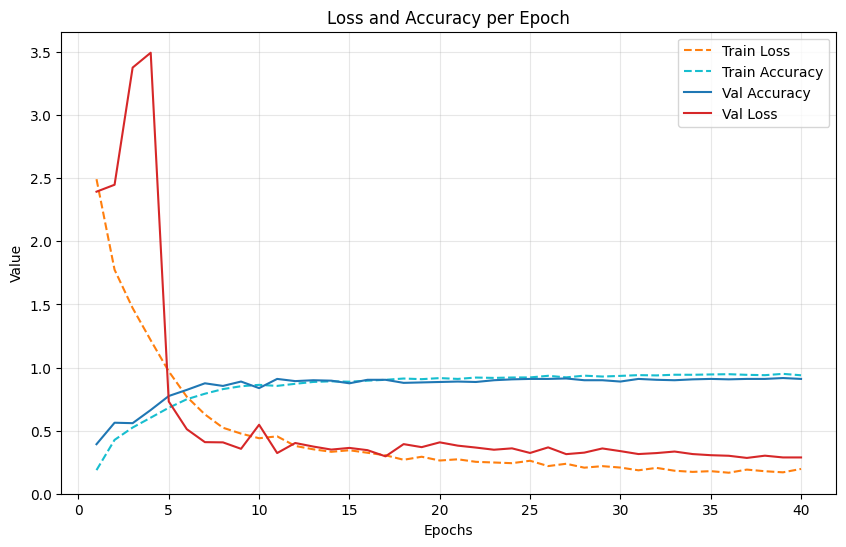

In [ ]:
# Exibe as acurácias e losses de treinamento e de validação
epochs = range(1, len(tl_history['train_loss']) + 1)
plt.figure(figsize=(10, 6))

plt.plot(epochs, tl_history['train_loss'], label='Train Loss', color='tab:orange', linestyle='--')
plt.plot(epochs, tl_history['train_acc'], label='Train Accuracy', color='tab:cyan', linestyle='--')

if validation:
  plt.plot(epochs, tl_history['val_acc'], label='Val Accuracy', color='tab:blue')
  plt.plot(epochs, tl_history['val_loss'], label='Val Loss', color='tab:red')

plt.title('Loss and Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Observe que obtivemos um desempenho muito superior com o *Transfer Learning + Fine Tuning* em comparação com o modelo anterior. As curvas de *acurácia* subiram rapidamente e se estabilizaram em torno de **90%**, enquanto as curvas de *loss* se estabilizaram em valores menores que **0.5**. No tópico seguinte, aprofundaremos mais nessa análise com a comparação de desempenhos.

<a name="6."></a>
## **6. Comparação: *From Scratch* X *Transfer Learning***

Nesse tópico, analisaremos as curvas de **acurácia** e **loss** dos dois modelos, a fim de levantarmos hipóteses sobre seus resultados.

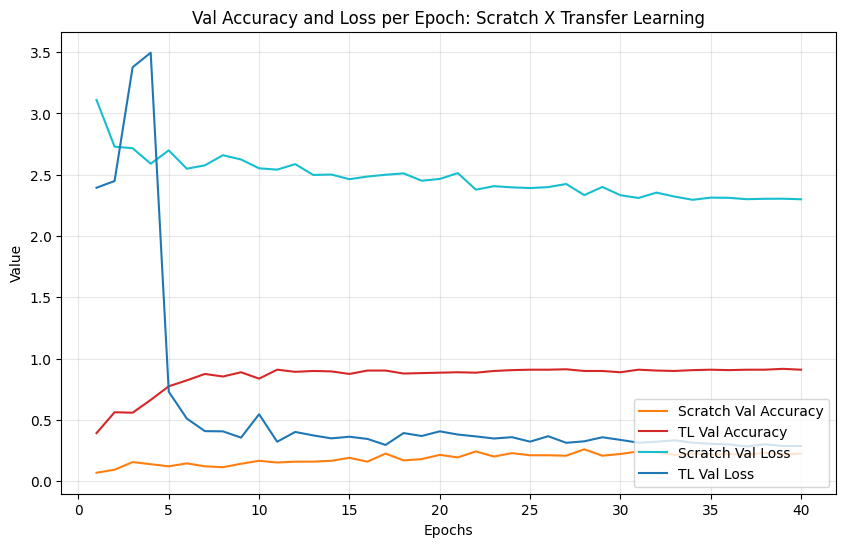

In [ ]:
# Exibe uma comparação das acurácias de validação dos 2 modelos
epochs = range(1, len(tl_history['train_loss']) + 1)
plt.figure(figsize=(10, 6))

plt.plot(epochs, scratch_history['val_acc'], label='Scratch Val Accuracy', color='tab:orange')
plt.plot(epochs, tl_history['val_acc'], label='TL Val Accuracy', color='tab:red')

plt.plot(epochs, scratch_history['val_loss'], label='Scratch Val Loss', color='tab:cyan')
plt.plot(epochs, tl_history['val_loss'], label='TL Val Loss', color='tab:blue')

plt.title('Val Accuracy and Loss per Epoch: Scratch X Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Value')
#plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

No gráfico, temos a evolução das métricas ao longo das 40 épocas para os modelos *from scratch* (**laranja**/**ciano**) e *pré-treinados* (**vermelho**/**azul**). Podemos observar que, em ambas as métricas, o modelo importado com *Fine Tuning* apresentou desempenho superior. Nesse sentido, podemos inferir alguns pontos importantes:

- O modelo *from scratch* foi inicializado com pesos aleatórios, seguindo algo semelhante a uma distribuição *gaussiana*. Isso significa que o modelo teve um esforço adicional para criar seus bancos de filtros e ajustar seus parâmetros;

- Por outro lado, o modelo importado já tinha seus parâmetros definidos em um banco de imagens seguro e, com a técnica de congelamento do backbone, o *Fine Tuning* foi capaz de trazer um ótimo desempenho para ele no nosso problema;

- Era esperado que houvesse uma diferença gritante entre os modelos. Naturalmente, redes pré-treinadas tendem a apresentar desempenhos superiores devido à sua característica de "não começar do zero".

<a name="7."></a>
## **7. Validação Final**

Após a análise do processo de treinamento dos dois modelos, seguiremos para uma validação final. Utilizaremos o nosso *Dataset* específico para validação sobre o modelo de *Fine Tuning* com melhor desempenho, a fim de obtermos uma métrica final de avaliação.

<a name="7.1."></a>
### *7.1. Importação e Análise Exploratória*

Iniciamos fazendo a importação do *Dataset* de validação, com transforms de *resize* + *tensorização*, e preparando o seu *Data Loader*.

In [ ]:
# Define os transforms para validação (resize e tensorização)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Define o loader do dataset com o transform adequado
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Depois, podemos fazer uma breve análise da quantidade de elementos do conjunto.

In [ ]:
# Prepara um Dataframe para o conjunto de validação
val_df = pd.DataFrame(data={
  'Nome Científico': val_dataset.classes,
  'Nome Popular': [names[name] for name in val_dataset.classes],
  'Contagem de Imagens': [len(os.listdir(os.path.join(val_dir, name))) for name in val_dataset.classes]
})

# Exibe informações do conjunto de validação
print(f'Total de imagens: {len(val_dataset)}\n')
val_df.style.set_caption("Contagem de Imagens por Classe")

Total de imagens: 113



,Nome Científico,Nome Popular,Contagem de Imagens
0,amazona_aestiva,Papagaio-verdadeiro,8
1,amazona_amazonica,Curica,8
2,anodorhynchus_hyacinthinus,Arara-azul,8
3,ara_ararauna,Arara-canindé,8
4,ara_chloropterus,Arara-vermelha,8
5,ara_macao,Araracanga,8
6,brotogeris_chiriri,Periquito-de-encontro-amarelo,8
7,diopsittaca_nobilis,Maracanã-pequena,8
8,eupsittula_aurea,Periquito-rei,8
9,forpus_xanthopterygius,Tuim,9


Observe que temos uma quantidade bem menor de elementos nesse conjunto. Entretanto, essas imagens tendem a possuir uma qualidade superior às de treinamento, uma vez que elas servirão apenas para avaliação de desempenho da rede.

**Obs:** *Os índices de linha da tabela correspondem aos targets utilizados pela rede.*

<a name="7.2."></a>
### *7.2. Predição do modelo*

Depois de prepararmos o *Dataset* de validação, vamos importar o modelo salvo com melhor acurácia de validação:

In [ ]:
# Recupera o checkpoint do modelo e carrega seus pesos
model = timm.create_model(model_name, pretrained=False)
model = replace_classifier_with_bottleneck(model, num_classes)
checkpoint = torch.load(tl_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)
model.eval()

# Informações do checkpoint
print(f"Loaded checkpoint:\n- epoch {checkpoint['epoch']}\n" \
      f"- {'val' if validation else 'train'}_loss {checkpoint['best_loss']:.4f}\n" \
      f"- {'val' if validation else 'train'}_acc {checkpoint['best_acc']*100:.2f}%")

Loaded checkpoint:
- epoch 39
- val_loss 0.2874
- val_acc 91.67%


Agora, realizaremos a predição desse modelo sobre o conjunto de validação, para avaliarmos as métricas da predição no [**próximo tópico**](#7.3.).

In [ ]:
# Definição de variáveis para predição
all_preds, all_labels = [], []
criterion = nn.CrossEntropyLoss()
test_correct, test_total, test_loss = 0, 0, 0.0

# Loop para predição do modelo sobre o conjunto de validação
with torch.no_grad():
  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    with amp.autocast('cuda'):
      outputs = model(inputs)
      loss = criterion(outputs, labels)

    test_loss += loss.item() * inputs.size(0)
    preds = outputs.argmax(dim=1)
    all_preds.append(preds.cpu().numpy())
    all_labels.append(labels.cpu().numpy())
    test_correct += (preds == labels).sum().item()
    test_total += labels.size(0)

# Cálculo das métricas de avaliação
test_loss = test_loss/test_total
test_acc = test_correct/test_total

<a name="7.3."></a>
### *7.3. Avaliação de desempenho*

Aqui, geraremos um *classification report*, observando os valores de *loss* e *accuracy* da predição.

In [ ]:
# Exibe as métricas da avaliação
print(f"Validation set Loss = {test_loss:.4f}")
print(f"Validation set Accuracy = {test_acc*100:.2f}%")

# Exibe o Classification Report
print("\n\nClassification Report:")
print(classification_report(np.concatenate(all_labels), np.concatenate(all_preds),
                            target_names=val_df['Nome Popular'], digits=4))

Validation set Loss = 0.1466
Validation set Accuracy = 97.35%


Classification Report:
                               precision    recall  f1-score   support

          Papagaio-verdadeiro     0.8889    1.0000    0.9412         8
                       Curica     1.0000    0.8750    0.9333         8
                   Arara-azul     1.0000    1.0000    1.0000         8
                Arara-canindé     1.0000    1.0000    1.0000         8
               Arara-vermelha     0.8889    1.0000    0.9412         8
                   Araracanga     1.0000    0.8750    0.9333         8
Periquito-de-encontro-amarelo     1.0000    0.8750    0.9333         8
             Maracanã-pequena     1.0000    1.0000    1.0000         8
                Periquito-rei     0.8889    1.0000    0.9412         8
                         Tuim     1.0000    1.0000    1.0000         9
           Maracanã-do-buriti     1.0000    1.0000    1.0000         9
                     Maracanã     1.0000    1.0000    1.0000

Obtivemos na validação uma acurácia muito satisfatória de **97,35%** e uma loss baixa de **0,1466**.

Vamos observar a contagem de erros e de acertos na **matriz de confusão** abaixo:

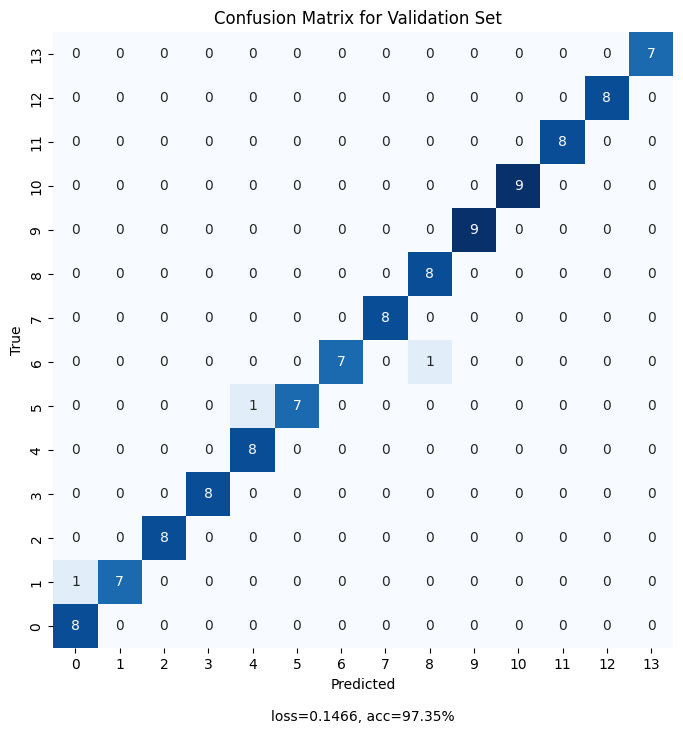

In [ ]:
# Geração da Matriz de Confusão
cm = confusion_matrix(np.concatenate(all_labels), np.concatenate(all_preds))
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel(f"Predicted\n\nloss={test_loss:.4f}, acc={test_acc*100:.2f}%")
plt.ylabel("True")
plt.title("Confusion Matrix for Validation Set  ")
plt.gca().invert_yaxis()
plt.show()

Perceba que o modelo importado com *Fine Tuning* acertou a grande maioria de suas previsões, apresentando apenas 3 casos de erro.

Vamos observar visualmente quais foram esses casos de erro na célula seguinte.

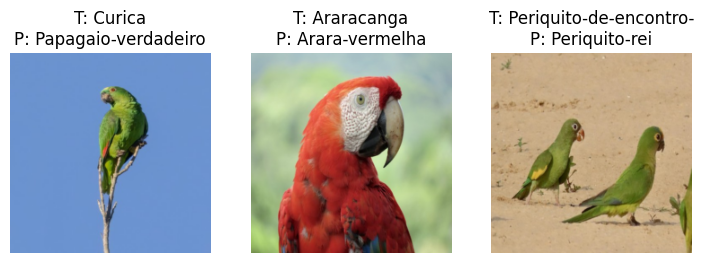

In [ ]:
# Visualização dos erros de predição
error_index = np.where(np.concatenate(all_preds) != np.concatenate(all_labels))[0] # Índices onde houve erro de previsão
plt.figure(figsize=(15, 6)) # Define o tamanho da imagem

for i, idx in enumerate(error_index):
    plt.subplot(2, 5, i + 1)
    plt.imshow(val_dataset[idx][0].permute(1, 2, 0))
    plt.title(f"T: {val_df['Nome Popular'][np.concatenate(all_labels)[idx]][:22]}\n" \
              f"P: {val_df['Nome Popular'][np.concatenate(all_preds)[idx]][:22]}") # Título: True (T) x Predicted (P)
    plt.axis('off') # Desativa a marcação dos eixos

Tivemos, nessa versão do modelo, os erros de predição apresentados acima. É importante pontuar que, esses casos de erro se repetiram na maioria das versões do modelo testadas anteriormente, ou seja, **o modelo tende a interpretar erroneamente essas três imagens**.

Vamos analisar cada uma delas abaixo:

- Na primeira imagem, temos uma **Curica**, uma ave verde com detalhes amarelos no rosto, olhos com tons alaranjados e, em alguns casos, detalhes azuis acima dos olhos e detalhes vermelhos na parte inferior da asa. Essas são todas características também apresentadas pelo **Papagaio-verdadeiro**. A diferença, sutil, está na textura das penas, no formato do corpo e na cor das pernas;

- Na segunda imagem, temos uma **Araracanga**, uma ave que costuma apresentar a parte superior do corpo avermelhada, e com a parte inferior das asas em tons azuis, verdes e amarelos. A diferença entre ela e a **Arara-vermelha** está no fato que esta apresenta tons mais azulados na asa. Na parte superior do corpo, destacada na imagem, as duas são muito semelhantes;

- Na terceira imagem, temos **Periquitos-de-encontro-amarelo**, aves uniformemente verde-amarelas, com círculos amarelos ao redor dos olhos, também presentes nos **Periquitos-rei**. Este, entretanto, possui colorações azuladas e menos uniformes pelo corpo.

<br>

Perceba que, nos três casos, temos situações e características que tornam difícil a classificação até mesmo para olhares humanos. Além disso, muitas vezes essa tarefa exige a visualização de detalhes que podem estar ausentes na imagem, como é o caso da **Araracanga**. Porém, apesar desses casos específicos, o nosso modelo obteve desempenho satisfatório na predição do *Dataset* de validação.

<a name="8."></a>
## **8. Resultados e Conclusão**

Após a elaboração de dois modelos diferentes utilizando o *framework* do *Pytorch*, um sendo elaborado "do zero", com seus parâmetros inicializados seguindo uma distribuição normal, e outro importado do *Pytorch* utilizando o `timm`, o *EfficientNetV2*, modificado para o contexto do problema e submetido a um *Fine Tuning* por 40 épocas, obtivemos resultados marcantes em ambos os casos que apontam para a existência de uma diferença fundamental no princípio dessas duas abordagens de desenvolvimento da rede.

Sendo submetidos ao *Dataset* contendo imagens de aves, divididas em 14 classes, no caso da rede *from scratch*, obtivemos uma acurácia de validação média de **21%** com dificuldade de crescimento, enquanto o modelo importado apresentou um valor próximo de **91%** no *Fine Tuning* e de **97%** na validação póstuma. Esses resultados atestam a expectativa de um desempenho superior da rede pré-treinada.

O desenvolvimento desse trabalho, que seguiu a metodologia definida em [*2. Metodologia*](#2.) foi extremamente proveitoso, uma vez que mostrou, de forma prática, as diferentes possibilidades de elaboração de uma **rede convolucional**, e como a escolha delas pode trazer resultados para tarefas diversas. Além disso, proporcionou também um aprofundamento do conhecimento no contexto das IA's.

<a name="9."></a>
## **9. Referências**

[[1]](#9.) JEEVAN, P; SETHI, A. **Which Backbone to Use: A Resource-efficient Domain Specific Comparison for Computer Vision.** Disponível em: https://arxiv.org/html/2406.05612v1.

[[2]](#9.) **Aprendizagem por Transferência com Camadas Congeladas em YOLOv5.** ultralytics. Disponível em: https://docs.ultralytics.com/pt/yolov5/tutorials/transfer_learning_with_frozen_layers.

[[3]](#9.) **AdamW.** PyTorch. Disponível em: https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html.